In [ ]:
import pandas as pd
import os

splits = ['neural', 'human']

for split in splits:
    txt_path = f'/content/my{split}.txt'
    csv_path = f'/content/my{split}.csv'

    with open(txt_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Разбиваем по '///' и убираем пустые строки
    texts = [seg.strip() for seg in content.split('///') if seg.strip()]

    df = pd.DataFrame({'text': texts})
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')

    print(f"{os.path.basename(txt_path)}: найдено {len(df)} записей → сохранено в {os.path.basename(csv_path)}")

myneural.txt: найдено 1000 записей → сохранено в myneural.csv
myhuman.txt: найдено 1000 записей → сохранено в myhuman.csv


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# !pip install pandas spacy nltk

In [ ]:
# модель spaсy для русского
# !python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 51.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import os
import pandas as pd
import spacy
from nltk.corpus import stopwords
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

In [ ]:
nlp = spacy.load("ru_core_news_sm")

In [ ]:
# русские стоп-слова
rus_stop = set(stopwords.words("russian"))

In [ ]:
extra_stop = {
    "это", "эта", "этот", "эти", "также", "тоже",
    "то", "та", "те", "очень", "еще", "ещё", "даже",
    "мочь", "свой", "весь", "своя", "свои", "вся", "все",
    "который", "которое", "которая", "которые", "ведь", "разве"
}

In [ ]:
def preprocess(text: str):
    text = re.sub(r"[^0-9A-Za-zА-Яа-яЁё\s]", " ", text)
    text = text.lower()
    doc = nlp(text)
    tokens = []
    for tok in doc:
        # лемматизация
        lemma = tok.lemma_.strip()
        # фильтрация
        if (
            lemma
            and lemma not in rus_stop
            and lemma not in extra_stop
            and len(lemma) > 1
            and not tok.is_punct
            and not tok.is_space
        ):
            tokens.append(lemma)
    return tokens

In [ ]:
for split in ("neural", "human"):
    txt_path = f"/content/my{split}.txt"
    csv_path = f"/content/my{split}.csv"

    with open(txt_path, encoding="utf-8") as f:
        segments = [seg.strip() for seg in f.read().split("///") if seg.strip()]

    df = pd.DataFrame({"raw_text": segments})
    df["tokens"] = df["raw_text"].apply(preprocess)
    df["clean_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

    df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    print(f"{txt_path}: сегментов {len(df)} → сохранено {csv_path}")

/content/myneural.txt: сегментов 1000 → сохранено /content/myneural.csv
/content/myhuman.txt: сегментов 1000 → сохранено /content/myhuman.csv


In [ ]:
df.head()

,raw_text,tokens,clean_text
0,"Доклад про Александра 2\n\nАлександр 2 жил с 1818 года по 1881 год. Правитель Российской империи, который за свое правление успел многое сделать для страны. Александр провел множество реформ: земская, судебная, военная и так же реформы в сфере финансов и государственного\nхозяйства. \nПосле земской реформы, начатой в 1864 году, стали формироваться выборные всесословные органы местного самоуправления, земства.\nСудебная реформа, проведенная в 1864 году, отделила судебную власть от исполнительной, законодательной и административной. Это обеспечивало независимость судебной системы. \nТак же в военной реформе Александр 2 сократил срок службы с 25 лет до 6 лет в армейском строю и до 7 лет на флоте.\nКлючевой реформой стала отмена крепостного права в 1861 году. И это событие стало одним из самых значимых событий в период правления Александра 2. Отмена крепостного права способствовала развитию капитализма в сельском хозяйстве и росту промышленности.\nТак же из успехов императора то, что он смог подавить множество восстаний, закончил Кавказскую войну и присоединил к России огромные территории. \nВ 1881 году Александр 2 скончался от брошенной в него бомбы.","[доклад, александр, александр, жить, 1818, год, 1881, год, правитель, российский, империя, правление, успеть, многое, сделать, страна, александр, провести, множество, реформа, земский, судебный, военный, реформа, сфера, финансов, государственный, хозяйство, земский, реформа, начать, 1864, год, стать, формироваться, выборный, всесословный, орган, местный, самоуправление, земство, судебный, реформа, провести, 1864, год, отделить, судебный, власть, исполнительный, законодательный, административный, обеспечивать, независимость, судебный, система, военный, реформа, александр, сократить, срок, служба, 25, год, год, армейский, строй, год, флот, ключевой, реформа, стать, отмена, крепостной, право, 1861, год, событие, стать, одним, самых, значимый, событие, период, правление, александр, отмена, крепостной, право, способствовать, развитие, капитализм, сельский, хозяйство, рост, промышленность, успех, император, смочь, подавить, ...]",доклад александр александр жить 1818 год 1881 год правитель российский империя правление успеть многое сделать страна александр провести множество реформа земский судебный военный реформа сфера финансов государственный хозяйство земский реформа начать 1864 год стать формироваться выборный всесословный орган местный самоуправление земство судебный реформа провести 1864 год отделить судебный власть исполнительный законодательный административный обеспечивать независимость судебный система военный реформа александр сократить срок служба 25 год год армейский строй год флот ключевой реформа стать отмена крепостной право 1861 год событие стать одним самых значимый событие период правление александр отмена крепостной право способствовать развитие капитализм сельский хозяйство рост промышленность успех император смочь подавить множество восстание закончить кавказский война присоединить россия огромный территория 1881 год александр скончаться бросить бомба
1,"Екатерина 2 родилась 21 апреля 1729 года в Германии. Имя данное при рождении: София Августа Фредерика Ангальт-Цербстская. До приезда в Россию, будущая императрица была добра, скромна и спокойна, но жизнь наградила её тяжёлыми испытаниями, которые отразились на её дальнейшем поведении и решениях. \nБыла избранна женой для будущего императора Петра 3. Была очень умна, поэтому свергал мужа и заняла трон в 1762 году. \nНесмотря на то, что Екатерина не была русской, она очень полюбила Россию и делала всё для её процветания. Она способствовала развитию культуры, образования, поддерживала искусство. Развивала экономику и торговлю, привлекала иностранных инвесторов.\nЗа период её правления территории России очень выросли. Например, завоевали земли на Кавказе и в Крыму. \nНесмотря на то, что Екатерина Великая была достойным правителем и сделала для России многое, не обошлось и без интриг и восс

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def show_wordcloud(texts, title, colormap):
    """
    texts: iterable строк (clean_text)
    title: заголовок графика
    colormap: строка с именем matplotlib-колоркарты
    """
    full_text = " ".join(texts)
    wc = WordCloud(
        width=600,
        height=600,
        background_color='white',
        collocations=False,
        regexp=r"\w+",
        colormap=colormap
    ).generate(full_text)

    plt.figure(figsize=(6, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# выбираем две разные «радуги»
colormaps = {
    "neural": "rainbow",        # полная радуга
    "human":  "nipy_spectral"   # другая радужная палитра
}

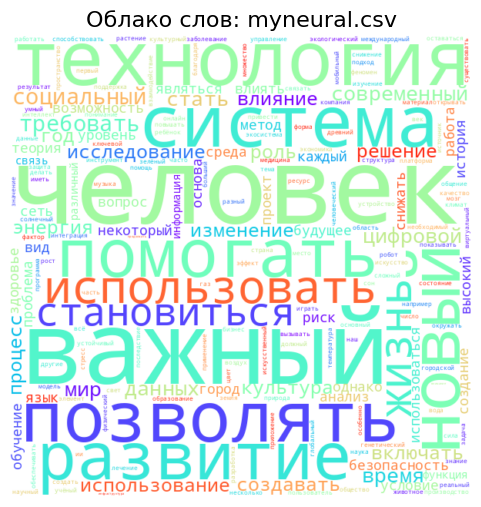

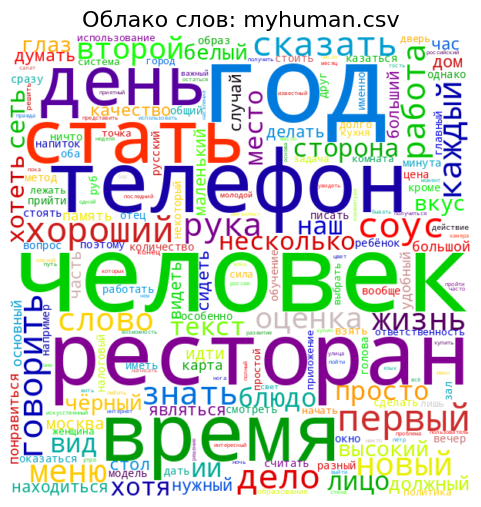

In [ ]:
for split in ("neural", "human"):
    csv_path = f"/content/my{split}.csv"
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    show_wordcloud(
        df["clean_text"].dropna(),
        f"Облако слов: my{split}.csv",
        colormap=colormaps[split]
    )

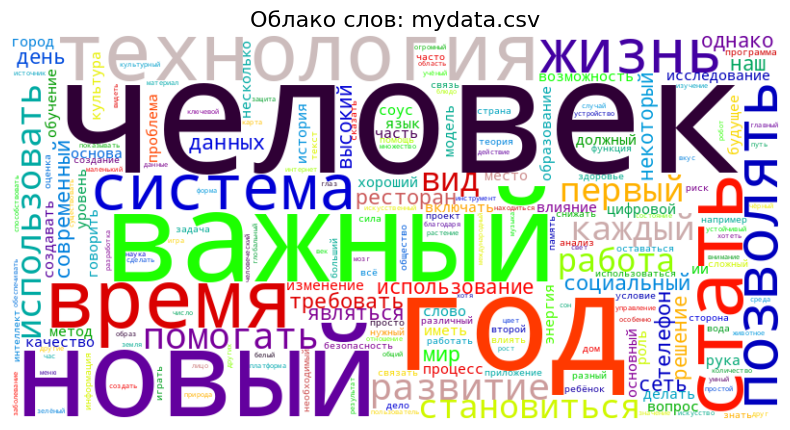

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Читаем данные из файла mydata.csv (предполагается наличие столбца "clean_text")
df = pd.read_csv("mydata.csv", encoding="utf-8-sig")

# Объединяем все строки столбца clean_text в одну большую строку
full_text = " ".join(df["clean_text"].dropna())

# Создаём и отображаем облако слов
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False,
    regexp=r"\w+",
    colormap="nipy_spectral"  # можно заменить на любую другую палитру, например "nipy_spectral"
).generate(full_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")

plt.title("Облако слов: mydata.csv", fontsize=16)
plt.show()


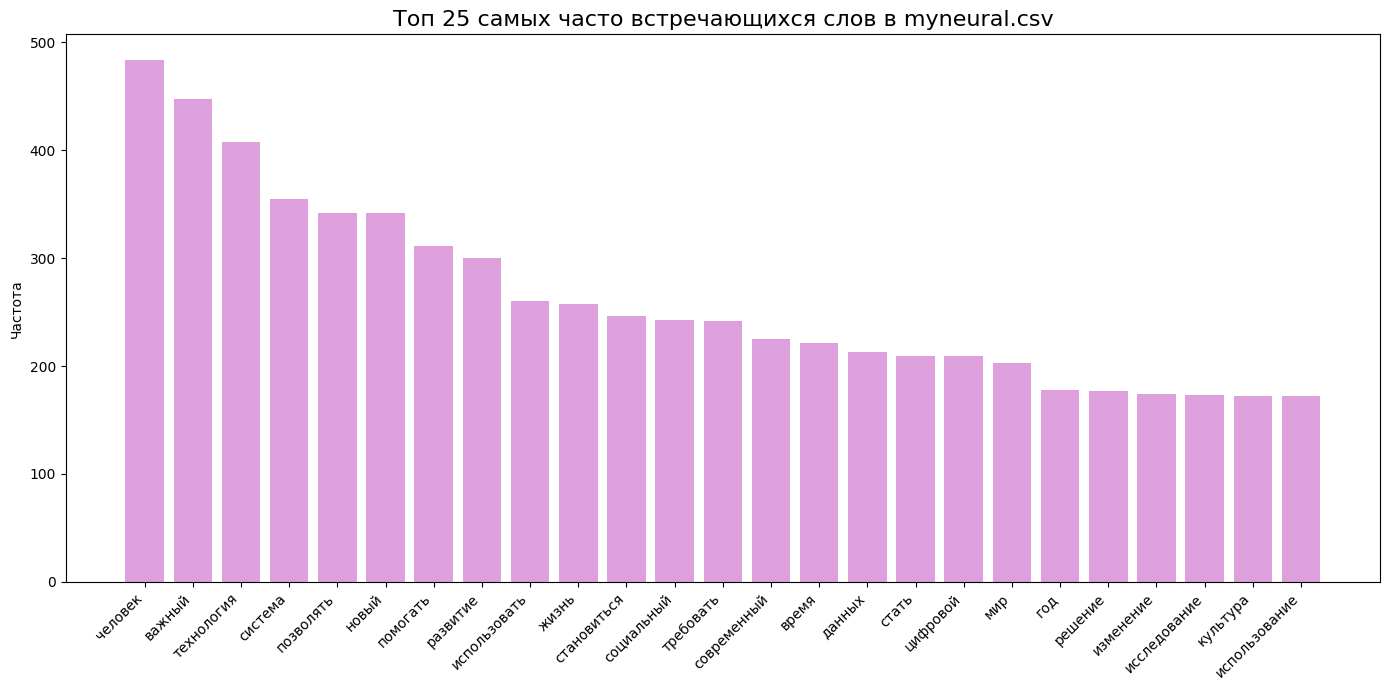

In [ ]:
from collections import Counter

df = pd.read_csv("/content/myneural.csv", encoding="utf-8-sig")

words = " ".join(df["clean_text"].dropna()).split()
counter = Counter(words)
top25 = counter.most_common(25)
labels, counts = zip(*top25)

plt.figure(figsize=(14, 7))
plt.bar(labels, counts, color="plum")
plt.xticks(rotation=45, ha='right')
plt.title("Топ 25 самых часто встречающихся слов в myneural.csv", fontsize=16)
plt.ylabel("Частота")
plt.tight_layout()
plt.show()


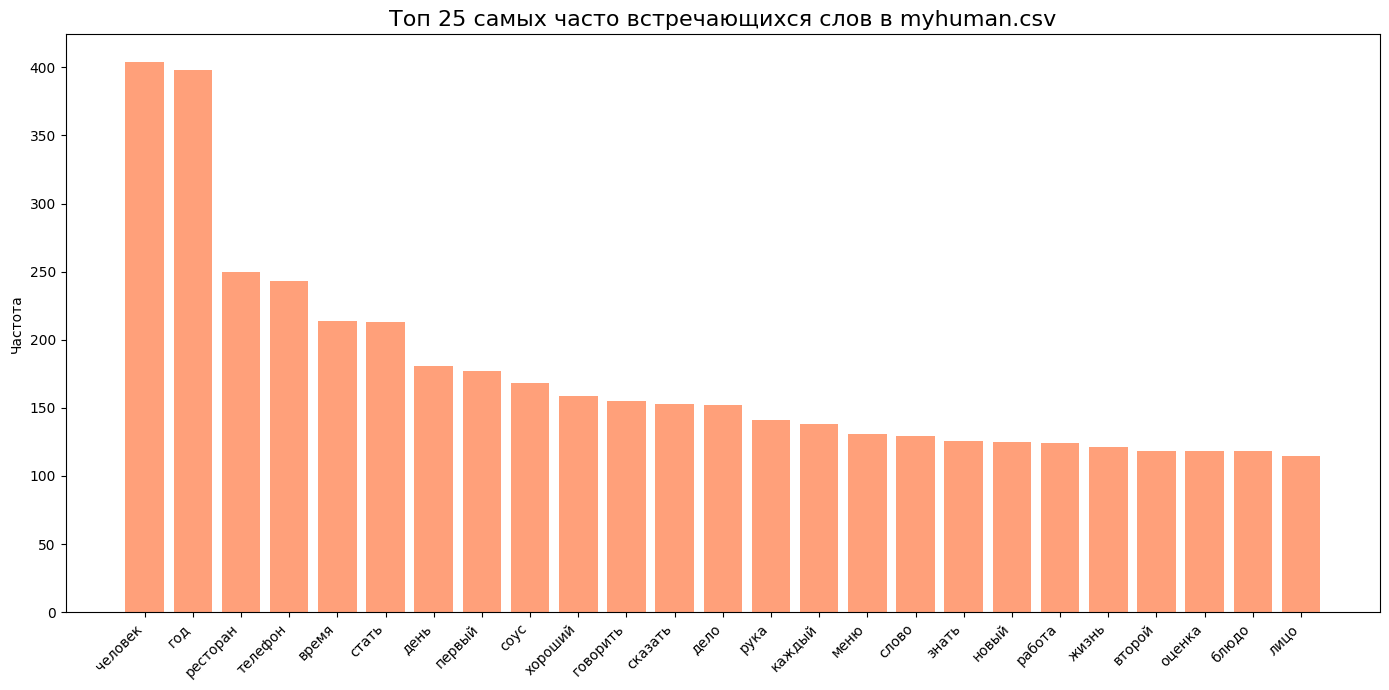

In [ ]:
df = pd.read_csv("/content/myhuman.csv", encoding="utf-8-sig")

words = " ".join(df["clean_text"].dropna()).split()
counter = Counter(words)
top25 = counter.most_common(25)
labels, counts = zip(*top25)

plt.figure(figsize=(14, 7))
plt.bar(labels, counts, color="lightsalmon")
plt.xticks(rotation=45, ha='right')
plt.title("Топ 25 самых часто встречающихся слов в myhuman.csv", fontsize=16)
plt.ylabel("Частота")
plt.tight_layout()
plt.show()


In [ ]:
df.head(10)

,raw_text,tokens,clean_text
0,"Доклад про Александра 2\n\nАлександр 2 жил с 1818 года по 1881 год. Правитель Российской империи, который за свое правление успел многое сделать для страны. Александр провел множество реформ: земская, судебная, военная и так же реформы в сфере финансов и государственного\nхозяйства. \nПосле земской реформы, начатой в 1864 году, стали формироваться выборные всесословные органы местного самоуправления, земства.\nСудебная реформа, проведенная в 1864 году, отделила судебную власть от исполнительной, законодательной и административной. Это обеспечивало независимость судебной системы. \nТак же в военной реформе Александр 2 сократил срок службы с 25 лет до 6 лет в армейском строю и до 7 лет на флоте.\nКлючевой реформой стала отмена крепостного права в 1861 году. И это событие стало одним из самых значимых событий в период правления Александра 2. Отмена крепостного права способствовала развитию капитализма в сельском хозяйстве и росту промышленности.\nТак же из успехов императора то, что он смог подавить множество восстаний, закончил Кавказскую войну и присоединил к России огромные территории. \nВ 1881 году Александр 2 скончался от брошенной в него бомбы.","['доклад', 'александр', 'александр', 'жить', '1818', 'год', '1881', 'год', 'правитель', 'российский', 'империя', 'правление', 'успеть', 'многое', 'сделать', 'страна', 'александр', 'провести', 'множество', 'реформа', 'земский', 'судебный', 'военный', 'реформа', 'сфера', 'финансов', 'государственный', 'хозяйство', 'земский', 'реформа', 'начать', '1864', 'год', 'стать', 'формироваться', 'выборный', 'всесословный', 'орган', 'местный', 'самоуправление', 'земство', 'судебный', 'реформа', 'провести', '1864', 'год', 'отделить', 'судебный', 'власть', 'исполнительный', 'законодательный', 'административный', 'обеспечивать', 'независимость', 'судебный', 'система', 'военный', 'реформа', 'александр', 'сократить', 'срок', 'служба', '25', 'год', 'год', 'армейский', 'строй', 'год', 'флот', 'ключевой', 'реформа', 'стать', 'отмена', 'крепостной', 'право', '1861', 'год', 'событие', 'стать', 'одним', 'самых', 'значимый', 'событие', 'период', 'правление', 'александр', 'отмена', 'крепостной', 'право', 'способствовать', 'развитие', 'капитализм', 'сельский', 'хозяйство', 'рост', 'промышленность', 'успех', 'император', 'смочь', 'подавить', 'множество', 'восстание', 'закончить', 'кавказский', 'война', 'присоединить', 'россия', 'огромный', 'территория', '1881', 'год', 'александр', 'скончаться', 'бросить', 'бомба']",доклад александр александр жить 1818 год 1881 год правитель российский империя правление успеть многое сделать страна александр провести множество реформа земский судебный военный реформа сфера финансов государственный хозяйство земский реформа начать 1864 год стать формироваться выборный всесословный орган местный самоуправление земство судебный реформа провести 1864 год отделить судебный власть исполнительный законодательный административный обеспечивать независимость судебный система военный реформа александр сократить срок служба 25 год год армейский строй год флот ключевой реформа стать отмена крепостной право 1861 год событие стать одним самых значимый событие период правление александр отмена крепостной право способствовать развитие капитализм сельский хозяйство рост промышленность успех император смочь подавить множество восстание закончить кавказский война присоединить россия огромный территория 1881 год александр скончаться бросить бомба
1,"Екатерина 2 родилась 21 апреля 1729 года в Германии. Имя данное при рождении: София Августа Фредерика Ангальт-Цербстская. До приезда в Россию, будущая императрица была добра, скромна и спокойна, но жизнь наградила её тяжёлыми испытаниями, которые отразились на её дальнейшем поведении и решениях. \nБыла избранна женой для будущего императора Петра 3. Была очень умна, поэтому свергал мужа и заняла трон в 1762 году. \nНесмотря на то, что Екатерина не была русской, она очень полюбила Россию и делала всё для её процветания. Он

In [ ]:
df_neural = pd.read_csv("/content/myneural.csv", encoding="utf-8-sig")

In [ ]:
df_human = pd.read_csv("/content/myhuman.csv", encoding="utf-8-sig")

In [ ]:
len(df_human)

1000

In [ ]:
# добавляем столбец label
df_neural['label'] = 1
df_human['label'] = 0

In [ ]:
# df_neural.head()
df_human.head(10)

,raw_text,tokens,clean_text,label
0,"Доклад про Александра 2\n\nАлександр 2 жил с 1818 года по 1881 год. Правитель Российской империи, который за свое правление успел многое сделать для страны. Александр провел множество реформ: земская, судебная, военная и так же реформы в сфере финансов и государственного\nхозяйства. \nПосле земской реформы, начатой в 1864 году, стали формироваться выборные всесословные органы местного самоуправления, земства.\nСудебная реформа, проведенная в 1864 году, отделила судебную власть от исполнительной, законодательной и административной. Это обеспечивало независимость судебной системы. \nТак же в военной реформе Александр 2 сократил срок службы с 25 лет до 6 лет в армейском строю и до 7 лет на флоте.\nКлючевой реформой стала отмена крепостного права в 1861 году. И это событие стало одним из самых значимых событий в период правления Александра 2. Отмена крепостного права способствовала развитию капитализма в сельском хозяйстве и росту промышленности.\nТак же из успехов императора то, что он смог подавить множество восстаний, закончил Кавказскую войну и присоединил к России огромные территории. \nВ 1881 году Александр 2 скончался от брошенной в него бомбы.","['доклад', 'александр', 'александр', 'жить', '1818', 'год', '1881', 'год', 'правитель', 'российский', 'империя', 'правление', 'успеть', 'многое', 'сделать', 'страна', 'александр', 'провести', 'множество', 'реформа', 'земский', 'судебный', 'военный', 'реформа', 'сфера', 'финансов', 'государственный', 'хозяйство', 'земский', 'реформа', 'начать', '1864', 'год', 'стать', 'формироваться', 'выборный', 'всесословный', 'орган', 'местный', 'самоуправление', 'земство', 'судебный', 'реформа', 'провести', '1864', 'год', 'отделить', 'судебный', 'власть', 'исполнительный', 'законодательный', 'административный', 'обеспечивать', 'независимость', 'судебный', 'система', 'военный', 'реформа', 'александр', 'сократить', 'срок', 'служба', '25', 'год', 'год', 'армейский', 'строй', 'год', 'флот', 'ключевой', 'реформа', 'стать', 'отмена', 'крепостной', 'право', '1861', 'год', 'событие', 'стать', 'одним', 'самых', 'значимый', 'событие', 'период', 'правление', 'александр', 'отмена', 'крепостной', 'право', 'способствовать', 'развитие', 'капитализм', 'сельский', 'хозяйство', 'рост', 'промышленность', 'успех', 'император', 'смочь', 'подавить', 'множество', 'восстание', 'закончить', 'кавказский', 'война', 'присоединить', 'россия', 'огромный', 'территория', '1881', 'год', 'александр', 'скончаться', 'бросить', 'бомба']",доклад александр александр жить 1818 год 1881 год правитель российский империя правление успеть многое сделать страна александр провести множество реформа земский судебный военный реформа сфера финансов государственный хозяйство земский реформа начать 1864 год стать формироваться выборный всесословный орган местный самоуправление земство судебный реформа провести 1864 год отделить судебный власть исполнительный законодательный административный обеспечивать независимость судебный система военный реформа александр сократить срок служба 25 год год армейский строй год флот ключевой реформа стать отмена крепостной право 1861 год событие стать одним самых значимый событие период правление александр отмена крепостной право способствовать развитие капитализм сельский хозяйство рост промышленность успех император смочь подавить множество восстание закончить кавказский война присоединить россия огромный территория 1881 год александр скончаться бросить бомба,0
1,"Екатерина 2 родилась 21 апреля 1729 года в Германии. Имя данное при рождении: София Августа Фредерика Ангальт-Цербстская. До приезда в Россию, будущая императрица была добра, скромна и спокойна, но жизнь наградила её тяжёлыми испытаниями, которые отразились на её дальнейшем поведении и решениях. \nБыла избранна женой для будущего императора Петра 3. Была очень умна, поэтому свергал мужа и заняла трон в 1762 году. \nНесмотря на то, что Екатерина не была русской, она очень полюбила Россию и делала всё для её процвет

In [ ]:
df = pd.concat([df_neural, df_human], ignore_index=True)

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df.to_csv('/content/mydata.csv', index=False, encoding='utf-8-sig')

In [ ]:
df.head(10)

,raw_text,tokens,clean_text,label
0,"Люблю людей, люблю своих клиентов, наши сеансы: вот я держу в руках ручку и еще пустой белый лист на планшете. \nЧто будет дальше? О чем мне расскажут и куда я их поведу? Мне нравится этот контакт. И нравится предвкушение этого контакта. \nНравится дышать эвкалиптом в бане, нравится смотреть в окно машины, нравится долго лежать проснувшись, изучая, как за ночь изменился комнатный замиокулькус. Нравится заходить в лифт и нажимать на кнопку, чувствуя, как меня поднимает вверх от земли. \nКогда у человека низкий уровень энергии, он может выделять из фона важное, не смакуя детали. Он существует, бегло, листая страницы, как студент, вынужденный подготовить к экзамену ненавистный, ненужный отрывок. Он не замечает жизнь. Когда энергия возрастает, возрастает внимание - жизнь ощущается совершенно иначе, слаще, детальнее, интереснее. В ней хочется быть.\nЕсли меня спросят, что самое важное для качественной жизни, я однозначно отвечу - энергия. Это то количество внимания, которое есть внутри вас. Это то количество впечатлений и деталей, которые вы можете взять от жизни. Не говоря уже о событиях, которые эту жизнь наполнят. \nЖелаю вам высокой энергии и ресурса. Научитесь управлять своей энергией и будьте внимательны к ней. \nЭто важнее всего материального. И это основа всего материального.","['любить', 'человек', 'любить', 'клиент', 'наш', 'сеанс', 'дерзить', 'рука', 'ручка', 'пустой', 'белый', 'лист', 'планшет', 'далёкий', 'рассказать', 'повести', 'нравиться', 'контакт', 'нравиться', 'предвкушение', 'контакт', 'нравиться', 'дышать', 'эвкалипт', 'баня', 'нравиться', 'смотреть', 'окно', 'машина', 'нравиться', 'долго', 'лежать', 'проснувшись', 'изучать', 'ночь', 'измениться', 'комнатный', 'замиокулькус', 'нравиться', 'заходить', 'лифт', 'нажимать', 'кнопка', 'чувствовать', 'поднимать', 'вверх', 'земля', 'человек', 'низкий', 'уровень', 'энергия', 'выделять', 'фон', 'важный', 'смаковать', 'деталь', 'существовать', 'бегло', 'листая', 'страница', 'студент', 'вынужденный', 'подготовить', 'экзамен', 'ненавистный', 'ненужный', 'отрывок', 'замечать', 'жизнь', 'энергия', 'возрастать', 'возрастать', 'внимание', 'жизнь', 'ощущаться', 'совершенно', 'иначе', 'сладкий', 'детальный', 'интересный', 'хотеться', 'спросят', 'самое', 'важный', 'качественный', 'жизнь', 'однозначно', 'ответить', 'энергия', 'количество', 'внимание', 'внутри', 'количество', 'впечатление', 'деталь', 'взять', 'жизнь', 'говорить', 'событие', 'жизнь', 'наполнить', 'желать', 'высокий', 'энергия', 'ресурс', 'научитесь', 'управлять', 'энергия', 'внимательный', 'важный', 'материальный', 'основа', 'материальный']",любить человек любить клиент наш сеанс дерзить рука ручка пустой белый лист планшет далёкий рассказать повести нравиться контакт нравиться предвкушение контакт нравиться дышать эвкалипт баня нравиться смотреть окно машина нравиться долго лежать проснувшись изучать ночь измениться комнатный замиокулькус нравиться заходить лифт нажимать кнопка чувствовать поднимать вверх земля человек низкий уровень энергия выделять фон важный смаковать деталь существовать бегло листая страница студент вынужденный подготовить экзамен ненавистный ненужный отрывок замечать жизнь энергия возрастать возрастать внимание жизнь ощущаться совершенно иначе сладкий детальный интересный хотеться спросят самое важный качественный жизнь однозначно ответить энергия количество внимание внутри количество впечатление деталь взять жизнь говорить событие жизнь наполнить желать высокий энергия ресурс научитесь управлять энергия внимательный важный материальный основа материальный,0
1,"Средневековые эпидемии: Влияние эпидемий на религиозные верования и практику в Средневековье.\n\nЭпидемии, такие как чума, тиф и оспа, регулярно поражали средневековое общество, унося жизни миллионов людей. Эти катастрофы оказывали огромное влияние на религиозные верования и практику. Люди видели в эпидемиях наказание за грехи, что приводило к усилению религиозного фанатизма, покаянным процессиям и п

In [ ]:
dff = pd.DataFrame()
dff['raw_text'] = df['raw_text']
dff['clean_text'] = df['clean_text']

In [ ]:
dff.head()

,raw_text,clean_text
0,"Люблю людей, люблю своих клиентов, наши сеансы: вот я держу в руках ручку и еще пустой белый лист на планшете. \nЧто будет дальше? О чем мне расскажут и куда я их поведу? Мне нравится этот контакт. И нравится предвкушение этого контакта. \nНравится дышать эвкалиптом в бане, нравится смотреть в окно машины, нравится долго лежать проснувшись, изучая, как за ночь изменился комнатный замиокулькус. Нравится заходить в лифт и нажимать на кнопку, чувствуя, как меня поднимает вверх от земли. \nКогда у человека низкий уровень энергии, он может выделять из фона важное, не смакуя детали. Он существует, бегло, листая страницы, как студент, вынужденный подготовить к экзамену ненавистный, ненужный отрывок. Он не замечает жизнь. Когда энергия возрастает, возрастает внимание - жизнь ощущается совершенно иначе, слаще, детальнее, интереснее. В ней хочется быть.\nЕсли меня спросят, что самое важное для качественной жизни, я однозначно отвечу - энергия. Это то количество внимания, которое есть внутри вас. Это то количество впечатлений и деталей, которые вы можете взять от жизни. Не говоря уже о событиях, которые эту жизнь наполнят. \nЖелаю вам высокой энергии и ресурса. Научитесь управлять своей энергией и будьте внимательны к ней. \nЭто важнее всего материального. И это основа всего материального.",любить человек любить клиент наш сеанс дерзить рука ручка пустой белый лист планшет далёкий рассказать повести нравиться контакт нравиться предвкушение контакт нравиться дышать эвкалипт баня нравиться смотреть окно машина нравиться долго лежать проснувшись изучать ночь измениться комнатный замиокулькус нравиться заходить лифт нажимать кнопка чувствовать поднимать вверх земля человек низкий уровень энергия выделять фон важный смаковать деталь существовать бегло листая страница студент вынужденный подготовить экзамен ненавистный ненужный отрывок замечать жизнь энергия возрастать возрастать внимание жизнь ощущаться совершенно иначе сладкий детальный интересный хотеться спросят самое важный качественный жизнь однозначно ответить энергия количество внимание внутри количество впечатление деталь взять жизнь говорить событие жизнь наполнить желать высокий энергия ресурс научитесь управлять энергия внимательный важный материальный основа материальный
1,"Средневековые эпидемии: Влияние эпидемий на религиозные верования и практику в Средневековье.\n\nЭпидемии, такие как чума, тиф и оспа, регулярно поражали средневековое общество, унося жизни миллионов людей. Эти катастрофы оказывали огромное влияние на религиозные верования и практику. Люди видели в эпидемиях наказание за грехи, что приводило к усилению религиозного фанатизма, покаянным процессиям и поискам виновных. Распространялись суеверия и магические обряды, направленные на защиту от болезней. Церковь укрепляла свою власть, предлагая духовное утешение и организуя помощь больным. Эпидемии порождали страх и отчаяние, но также стимулировали развитие благотворительности и медицинских знаний.",средневековый эпидемия влияние эпидемия религиозный верование практика средневековье эпидемия чума тиф оспа регулярно поражали средневековый общество унося жизнь миллион человек катастрофа оказывать огромный влияние религиозный верование практика человек видеть эпидемиях наказание грех приводить усиление религиозный фанатизм покаянный процессия поиск виновный распространяться суеверия магический обряд направить защита болезнь церковь укреплять власть предлагать духовный утешение организовать помощь больным эпидемия порождали страх отчаяние стимулировать развитие благотворительность медицинский знание
2,"Алеша, войдя, сообщил Ивану Федоровичу, что час с небольшим назад прибежала к нему на квартиру Марья Кондратьевна и объявила, что Смердяков лишил себя жизни. «Вхожу этта к нему самовар прибрать, а он у стенки на гвоздочке висит». На вопрос Алеши: «Заявила ль она кому следует?» – ответила, что никому не заявляла, а «прямо бросилась к вам к первому и всю дорогу бежала бегом». Она была как помешанная, п

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

In [ ]:
# Загрузка данных
df = pd.read_csv('/content/mydata.csv', encoding='utf-8-sig')

In [ ]:
# Преобразуем столбец tokens из строкового представления списка в настоящий список
df['tokens_list'] = df['tokens'].apply(ast.literal_eval)

In [ ]:
# Считаем длины
df['token_len'] = df['tokens_list'].apply(len)
df['char_len'] = df['raw_text'].astype(str).apply(len)

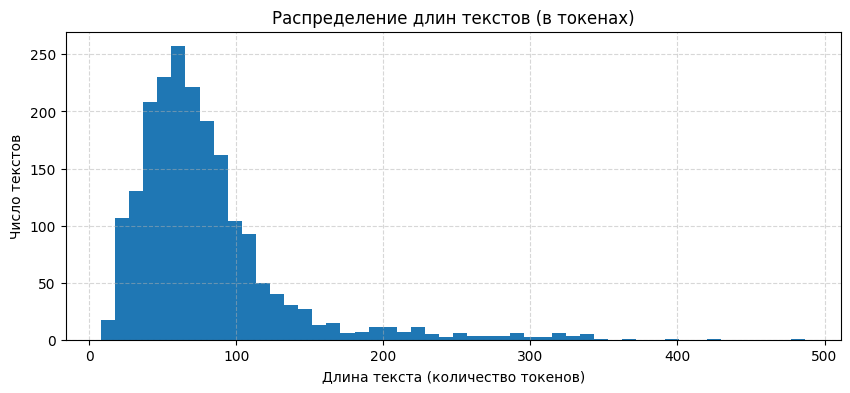

In [ ]:
# Гистограмма распределения по числу токенов
plt.figure(figsize=(10, 4))
plt.hist(df['token_len'], bins=50)
plt.title('Распределение длин текстов (в токенах)')
plt.xlabel('Длина текста (количество токенов)')
plt.ylabel('Число текстов')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

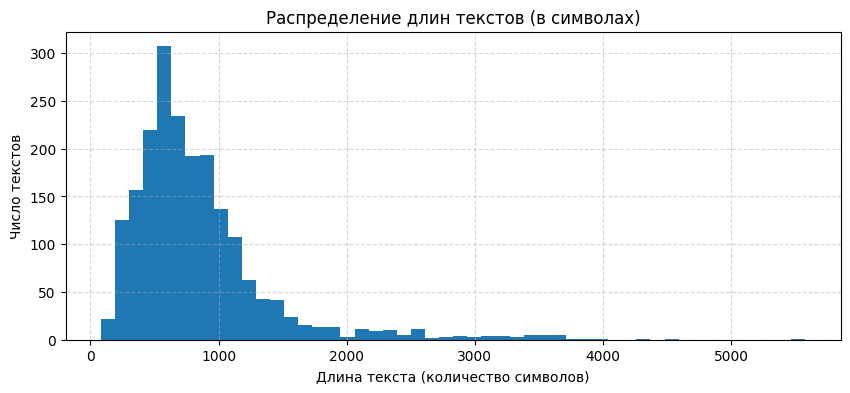

In [ ]:
# Гистограмма распределения по числу символов
plt.figure(figsize=(10, 4))
plt.hist(df['char_len'], bins=50)
plt.title('Распределение длин текстов (в символах)')
plt.xlabel('Длина текста (количество символов)')
plt.ylabel('Число текстов')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Загрузка данных
df_data = pd.read_csv('/content/mydata.csv', encoding='utf-8-sig')
df_neural = pd.read_csv('/content/myneural.csv', encoding='utf-8-sig')
df_human = pd.read_csv('/content/myhuman.csv', encoding='utf-8-sig')

In [ ]:
# Преобразуем столбец tokens из строкового представления списка в настоящий список
df_data['tokens_list'] = df_data['tokens'].apply(ast.literal_eval)
df_neural['tokens_list'] = df_neural['tokens'].apply(ast.literal_eval)
df_human['tokens_list'] = df_human['tokens'].apply(ast.literal_eval)

In [ ]:
# Функция для получения частот слов
def get_freq_dict(tokens_lists):
    all_tokens = [token for tokens in tokens_lists for token in tokens]
    freq_dict = {}
    for token in all_tokens:
        freq_dict[token] = freq_dict.get(token, 0) + 1
    return freq_dict

# Частотные словари для каждого файла
freq_data = get_freq_dict(df_data['tokens_list'])
freq_neural = get_freq_dict(df_neural['tokens_list'])
freq_human = get_freq_dict(df_human['tokens_list'])

In [ ]:
# Функция для построения группированного столбчатого графика
def plot_grouped_bar(words, freq_dicts, labels, title):
    """
    words: список слов для отображения
    freq_dicts: список частотных словарей (по порядку labels)
    labels: подписи для каждого набора данных
    title: заголовок графика
    """
    x = np.arange(len(words))
    width = 0.25  # Ширина каждой группы баров

    # Создаем фигуру и оси
    plt.figure(figsize=(14, 7))

    # Строим бары для каждого словаря
    for i, freq in enumerate(freq_dicts):
        counts = [freq.get(word, 0) for word in words]
        plt.bar(x + i * width, counts, width, label=labels[i])

    # Настройки осей и меток
    plt.xticks(x + width, words, rotation=45, ha='right')
    plt.ylabel('Частота')
    plt.title(title, fontsize=16)
    plt.legend()
    plt.tight_layout()
    plt.show()

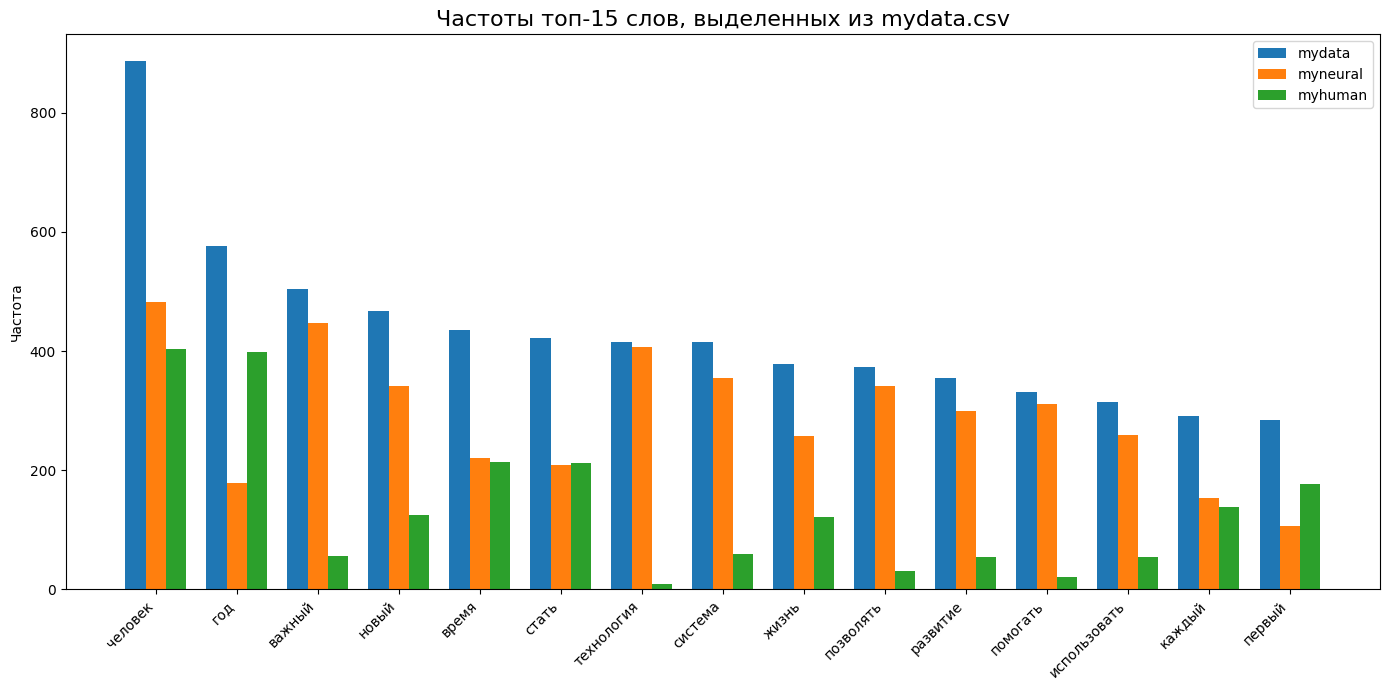

In [ ]:
# 1) Топ 15 слов из mydata.csv
top15_data = sorted(freq_data.items(), key=lambda x: x[1], reverse=True)[:15]
words_data = [word for word, _ in top15_data]

# Построение графика для топ15 из mydata.csv во всех трех файлах
plot_grouped_bar(
    words_data,
    [freq_data, freq_neural, freq_human],
    ['mydata', 'myneural', 'myhuman'],
    'Частоты топ-15 слов, выделенных из mydata.csv'
)

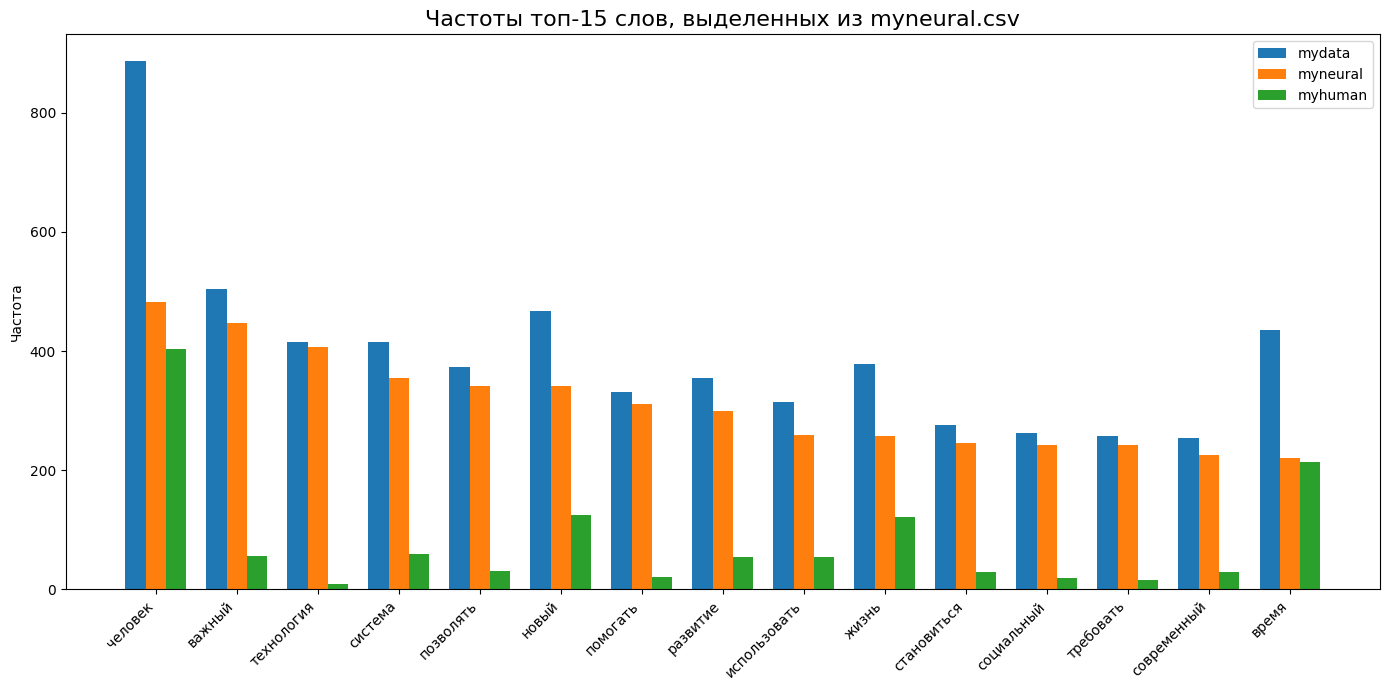

In [ ]:
# 2) Топ 15 слов из myneural.csv
top15_neural = sorted(freq_neural.items(), key=lambda x: x[1], reverse=True)[:15]
words_neural = [word for word, _ in top15_neural]

# Построение графика для топ15 из myneural.csv во всех трех файлах
plot_grouped_bar(
    words_neural,
    [freq_data, freq_neural, freq_human],
    ['mydata', 'myneural', 'myhuman'],
    'Частоты топ-15 слов, выделенных из myneural.csv'
)

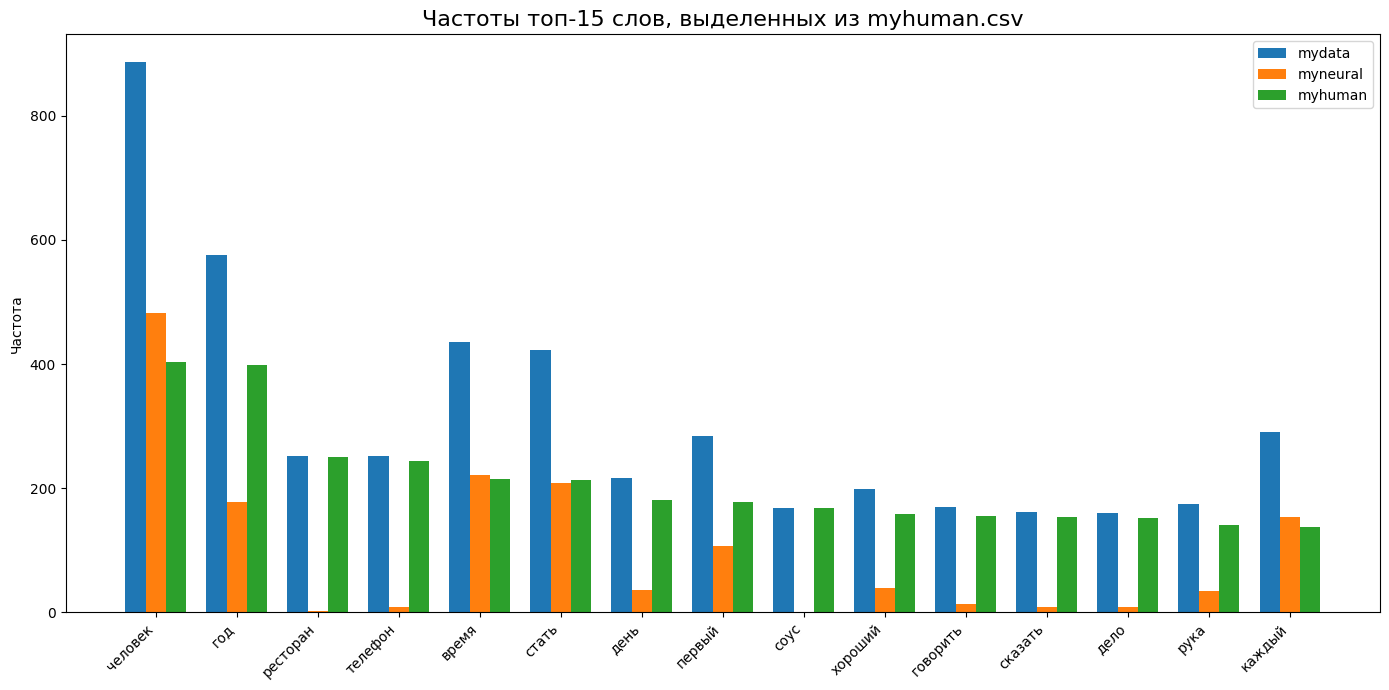

In [ ]:
# 3) Топ 15 слов из myhuman.csv
top15_human = sorted(freq_human.items(), key=lambda x: x[1], reverse=True)[:15]
words_human = [word for word, _ in top15_human]

# Построение графика для топ15 из myhuman.csv во всех трех файлах
plot_grouped_bar(
    words_human,
    [freq_data, freq_neural, freq_human],
    ['mydata', 'myneural', 'myhuman'],
    'Частоты топ-15 слов, выделенных из myhuman.csv'
)


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

In [ ]:
# -----------------------------------------------------------------------------
#  Настройте эти переменные, указав реальный путь к вашим CSV-файлам:
# -----------------------------------------------------------------------------
MYDATA_PATH   = '/content/mydata.csv'
MYNEURAL_PATH = '/content/myneural.csv'
MYHUMAN_PATH  = '/content/myhuman.csv'

In [ ]:
# -----------------------------------------------------------------------------
#  1. Читаем объединённый датасет (mydata.csv), обучаем LDA и выводим топ-10 слов по темам
# -----------------------------------------------------------------------------
df_all = pd.read_csv(MYDATA_PATH, encoding='utf-8-sig')
docs_all = df_all['clean_text'].dropna().tolist()

vectorizer = CountVectorizer(max_df=0.95, min_df=2)
dtm_all = vectorizer.fit_transform(docs_all)

n_topics = 10
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm_all)

feature_names = vectorizer.get_feature_names_out()
n_top_words = 10

print('=== Топ-10 слов для каждой из 10 тем (mydata.csv) ===\n')
for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[:-n_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = topic[top_indices]
    print(f"Тема {topic_idx + 1}:")
    for word, score in zip(top_words, top_scores):
        print(f"  {word} ({int(score)})")
    print()

=== Топ-10 слов для каждой из 10 тем (mydata.csv) ===

Тема 1:
  система (123)
  робот (110)
  технология (96)
  позволять (96)
  умный (89)
  новый (83)
  снижать (81)
  город (80)
  городской (78)
  приложение (70)

Тема 2:
  важный (333)
  человек (293)
  технология (233)
  помогать (230)
  развитие (226)
  позволять (216)
  система (201)
  новый (193)
  данных (188)
  требовать (178)

Тема 3:
  слово (44)
  человек (42)
  год (40)
  каждый (38)
  старый (38)
  время (35)
  петрович (35)
  глаз (33)
  вид (30)
  маникюр (30)

Тема 4:
  год (293)
  стать (139)
  человек (91)
  война (91)
  время (82)
  история (80)
  россия (68)
  первый (67)
  век (62)
  русский (58)

Тема 5:
  теория (108)
  функция (73)
  число (59)
  система (37)
  квантовый (36)
  математика (35)
  простой (34)
  сайт (32)
  иммунный (31)
  анализ (30)

Тема 6:
  ресторан (204)
  соус (168)
  блюдо (120)
  меню (112)
  оценка (109)
  вкус (95)
  напиток (70)
  понравиться (68)
  руб (65)
  масло (55)

Тема 7:
  

In [ ]:
# -----------------------------------------------------------------------------
#  2. Функция для получения среднего распределения тем в выбранном наборе
# -----------------------------------------------------------------------------
def get_avg_topic_distribution(csv_path, vectorizer, lda_model):
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    docs = df['clean_text'].dropna().tolist()
    dtm = vectorizer.transform(docs)
    topic_dist = lda_model.transform(dtm)     # n_docs x n_topics
    return topic_dist.mean(axis=0)             # усредняем по всем документам

In [ ]:
# -----------------------------------------------------------------------------
#  3. Берём средние распределения по темам для myneural.csv и для myhuman.csv
# -----------------------------------------------------------------------------
avg_neural = get_avg_topic_distribution(MYNEURAL_PATH, vectorizer, lda)
avg_human  = get_avg_topic_distribution(MYHUMAN_PATH, vectorizer, lda)

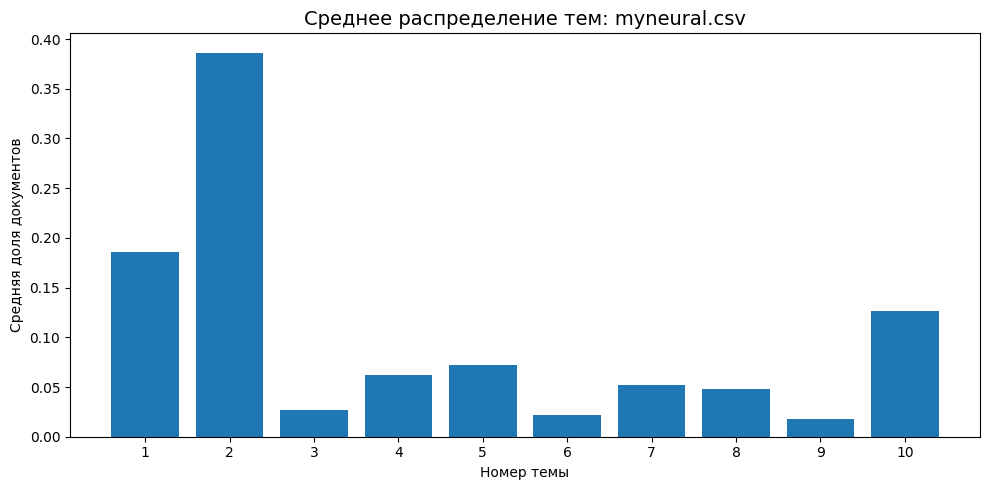

In [ ]:
# -----------------------------------------------------------------------------
#  4. Строим два отдельных графика: распределение тем для neural и для human
# -----------------------------------------------------------------------------
# 4.1. Распределение тем для myneural.csv
plt.figure(figsize=(10, 5))
plt.bar(range(1, n_topics + 1), avg_neural)
plt.xlabel('Номер темы')
plt.ylabel('Средняя доля документов')
plt.title('Среднее распределение тем: myneural.csv', fontsize=14)
plt.xticks(range(1, n_topics + 1))
plt.tight_layout()
plt.show()

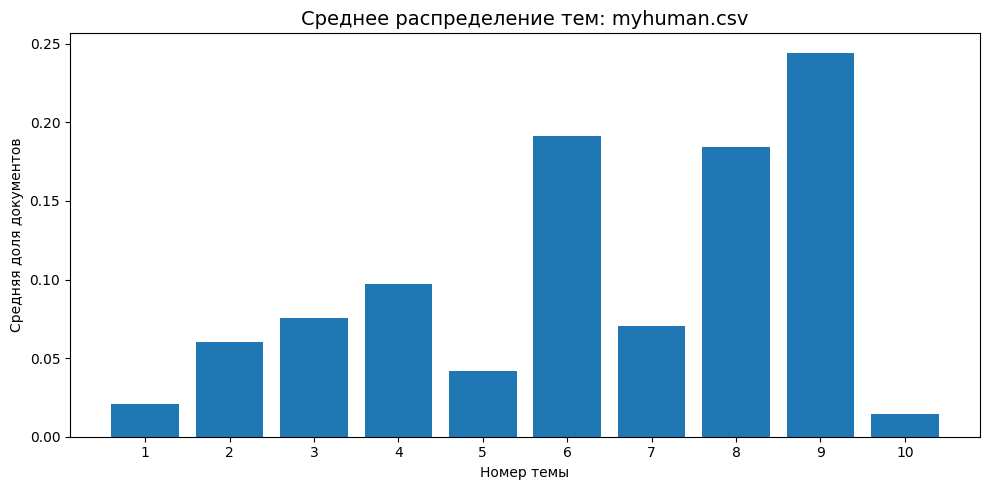

In [ ]:
# 4.2. Распределение тем для myhuman.csv
plt.figure(figsize=(10, 5))
plt.bar(range(1, n_topics + 1), avg_human)
plt.xlabel('Номер темы')
plt.ylabel('Средняя доля документов')
plt.title('Среднее распределение тем: myhuman.csv', fontsize=14)
plt.xticks(range(1, n_topics + 1))
plt.tight_layout()
plt.show()